# Comparación de K-Means, PCA + K-Means y Autoencoder + K-Means sobre MNIST

Objetivo

Comparar tres estrategias de agrupamiento sobre el conjunto de datos MNIST:

1. K-Means directamente sobre los píxeles originales.
2. PCA para reducir la dimensionalidad y luego K-Means.
3. Autoencoder para aprender una representación latente y luego K-Means.

La comparación permite observar si una representación aprendida mediante un autoencoder produce grupos más útiles que trabajar directamente con los datos originales o con una reducción lineal mediante PCA.

Importante: las etiquetas reales de los dígitos no se utilizan para entrenar K-Means, PCA ni el autoencoder. Solo se usan al final para evaluar qué tan bien los grupos recuperan la estructura conocida del conjunto de datos.

## 1. Importar librerías

Se utilizarán:

- TensorFlow/Keras para cargar MNIST y construir el autoencoder.
- scikit-learn para PCA, K-Means y métricas de evaluación.
- Matplotlib para visualizar los resultados.
- Pandas para construir las tablas comparativas.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from scipy.optimize import linear_sum_assignment

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

## 2. Cargar y preparar MNIST

MNIST contiene imágenes de 28 × 28 píxeles correspondientes a dígitos entre 0 y 9.

Cada imagen tiene:

28 × 28 = 784 características

Para los tres experimentos se utilizará exactamente el mismo subconjunto de observaciones. Esto permite que la comparación sea más justa y reduce el tiempo de ejecución durante la clase.

In [2]:
# Cargar MNIST
(X_train_img, y_train), (X_test_img, y_test) = keras.datasets.mnist.load_data()

print("Forma del conjunto de entrenamiento:", X_train_img.shape)
print("Forma de las etiquetas:", y_train.shape)

Forma del conjunto de entrenamiento: (60000, 28, 28)
Forma de las etiquetas: (60000,)


In [3]:
# Seleccionar un subconjunto estratificado para acelerar el experimento
N_SAMPLES = 20000

indices = np.arange(len(X_train_img))
indices_sel, _ = train_test_split(
    indices,
    train_size=N_SAMPLES,
    stratify=y_train,
    random_state=RANDOM_STATE
)

X_img = X_train_img[indices_sel]
y = y_train[indices_sel]

# Normalizar los píxeles al intervalo [0, 1]
X = X_img.astype("float32") / 255.0

# Vectorizar cada imagen: 28 x 28 -> 784
X = X.reshape(len(X), -1)

print("Número de observaciones:", X.shape[0])
print("Número de características:", X.shape[1])
print("Rango de valores:", X.min(), "a", X.max())

Número de observaciones: 20000
Número de características: 784
Rango de valores: 0.0 a 1.0


### Visualizar algunas observaciones

Antes de aplicar los métodos de agrupamiento conviene recordar la naturaleza de los datos originales.

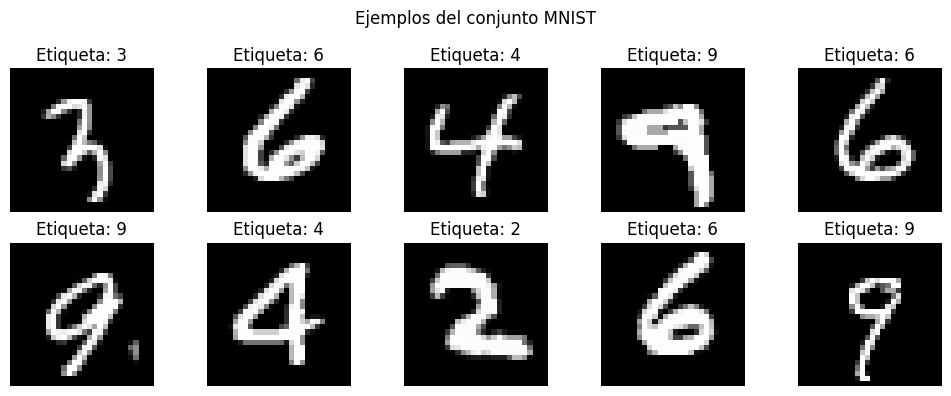

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_img[i], cmap="gray")
    ax.set_title(f"Etiqueta: {y[i]}")
    ax.axis("off")

plt.suptitle("Ejemplos del conjunto MNIST")
plt.tight_layout()
plt.show()

## 3. Experimento 1: K-Means directamente sobre los datos originales

En este primer experimento K-Means recibe directamente los vectores de 784 características.

No se realiza reducción de dimensionalidad antes del agrupamiento.

La pregunta es:

¿Puede K-Means identificar adecuadamente los diez grupos cuando trabaja directamente en el espacio de 784 dimensiones?

In [5]:
N_CLUSTERS = 10

inicio = time.perf_counter()

kmeans_direct = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
labels_direct = kmeans_direct.fit_predict(X)
tiempo_direct = time.perf_counter() - inicio

print(f"Tiempo K-Means directo: {tiempo_direct:.2f} s")
print("Forma de los datos usados por K-Means:", X.shape)

Tiempo K-Means directo: 18.29 s
Forma de los datos usados por K-Means: (20000, 784)


### Visualización de los grupos encontrados

Como los datos tienen 784 dimensiones, no pueden representarse directamente en una gráfica 2D.

Para visualizar únicamente el resultado se proyectan los datos a dos componentes principales. Esta proyección no participa en el entrenamiento del K-Means anterior; se utiliza solo para construir la figura.

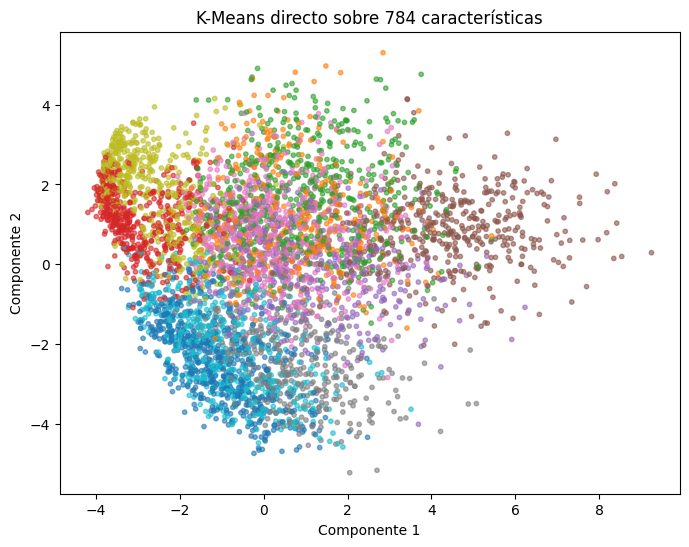

In [6]:
# Proyección 2D utilizada solamente para visualización
pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
X_visual = pca_visual.fit_transform(X)

muestra_plot = np.random.RandomState(RANDOM_STATE).choice(
    len(X), size=min(5000, len(X)), replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(
    X_visual[muestra_plot, 0],
    X_visual[muestra_plot, 1],
    c=labels_direct[muestra_plot],
    cmap="tab10",
    s=10,
    alpha=0.6
)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("K-Means directo sobre 784 características")
plt.show()

## 4. Experimento 2: PCA + K-Means

PCA transforma los 784 píxeles originales en un espacio de menor dimensión mediante combinaciones lineales.

Para hacer una comparación más directa con el autoencoder, se utilizará el mismo número de dimensiones en ambos métodos de reducción.

En este ejemplo: 784 dimensiones → 100 componentes principales. Luego K-Means se aplica sobre esa nueva representación.

In [7]:
LATENT_DIM = 100

inicio = time.perf_counter()
pca = PCA(n_components=LATENT_DIM, svd_solver="randomized", random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
kmeans_pca = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
labels_pca = kmeans_pca.fit_predict(X_pca)
tiempo_pca = time.perf_counter() - inicio

print("Forma después de PCA:", X_pca.shape)
print(f"Varianza acumulada explicada: {pca.explained_variance_ratio_.sum():.4f}")
print(f"Tiempo PCA + K-Means: {tiempo_pca:.2f} s")

Forma después de PCA: (20000, 100)
Varianza acumulada explicada: 0.9145
Tiempo PCA + K-Means: 1.96 s


### Varianza explicada por PCA

La curva acumulada permite observar cuánta varianza de los datos originales se conserva al aumentar el número de componentes.

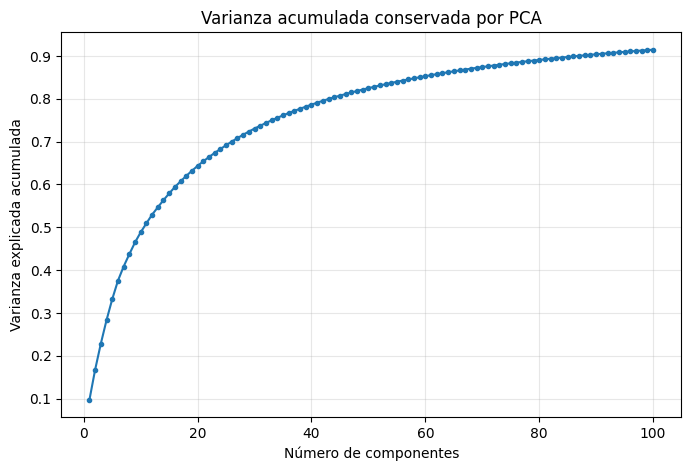

In [8]:
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, LATENT_DIM + 1), var_acum, marker="o", markersize=3)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza acumulada conservada por PCA")
plt.grid(True, alpha=0.3)
plt.show()

### Visualización de PCA + K-Means

Los dos primeros componentes se utilizan para representar los grupos encontrados por K-Means.

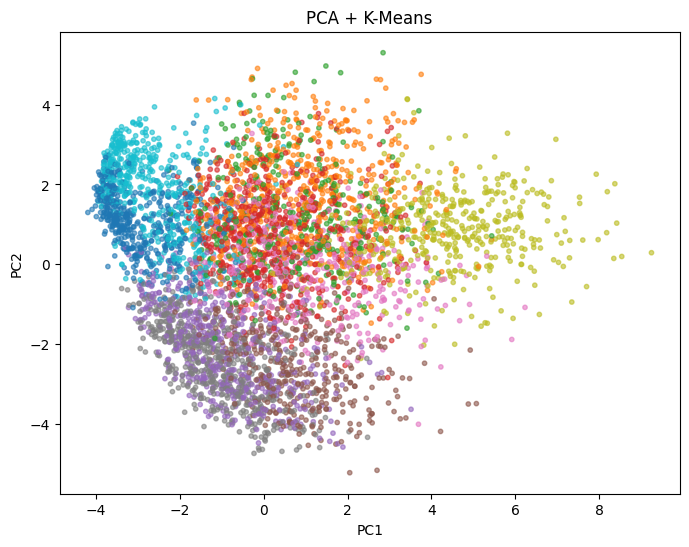

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[muestra_plot, 0],
    X_pca[muestra_plot, 1],
    c=labels_pca[muestra_plot],
    cmap="tab10",
    s=10,
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + K-Means")
plt.show()

## 5. Experimento 3: Autoencoder + K-Means

Ahora se aprenderá una representación de 100 dimensiones mediante un autoencoder.

La arquitectura utilizada es:
784 → 256 → 128 → 100 → 128 → 256 → 784

El encoder aprende la transformación:

x → z

El decoder utiliza z para reconstruir la entrada:

z → x̂

El autoencoder se entrena minimizando el error de reconstrucción entre x y x̂.

Después del entrenamiento se conserva únicamente el encoder para obtener la representación latente de cada observación. K-Means se aplica sobre ese espacio latente.

In [10]:
# Construir el encoder
encoder = keras.Sequential(
    [
        layers.Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(LATENT_DIM, activation="linear", name="espacio_latente"),
    ], name="encoder"
)

# Construir el decoder
decoder = keras.Sequential(
    [
        layers.Input(shape=(LATENT_DIM,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(784, activation="sigmoid"),
    ], name="decoder"
)

# Autoencoder completo
entrada = keras.Input(shape=(784,))
z = encoder(entrada)
salida = decoder(z)

autoencoder = keras.Model(entrada, salida, name="autoencoder")
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Sequential)                 │ (None, 100)                 │         246,756 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Sequential)                 │ (None, 784)                 │         247,440 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 494,196 (1.89 MB)

 Trainable params: 494,196 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el autoencoder

Se utiliza EarlyStopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.

In [11]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

inicio = time.perf_counter()

historia = autoencoder.fit(X, X, validation_split=0.10, epochs=50,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stopping],
    verbose=1)

tiempo_entrenamiento_ae = time.perf_counter() - inicio

print(f"Tiempo de entrenamiento del autoencoder: {tiempo_entrenamiento_ae:.2f} s")

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0837 - val_loss: 0.0551
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0414 - val_loss: 0.0325
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0275 - val_loss: 0.0241
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0221 - val_loss: 0.0204
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0188 - val_loss: 0.0180
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0165 - val_loss: 0.0166
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0153 - val_loss: 0.0150
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0141 - val_loss: 0.0139
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 - val_loss: 0.0131
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0116 - val_loss: 0.0118
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0112 - val_lo

### Curva de aprendizaje

La pérdida de entrenamiento y validación permite observar si el autoencoder está aprendiendo a reconstruir las imágenes y si el entrenamiento se estabiliza.

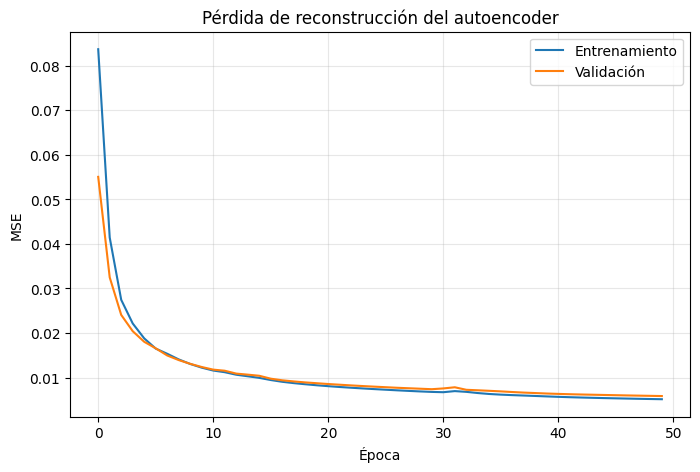

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(historia.history["loss"], label="Entrenamiento")
plt.plot(historia.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Pérdida de reconstrucción del autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observar reconstrucciones

Una forma sencilla de comprobar qué aprendió el autoencoder es comparar algunas imágenes originales con sus reconstrucciones.

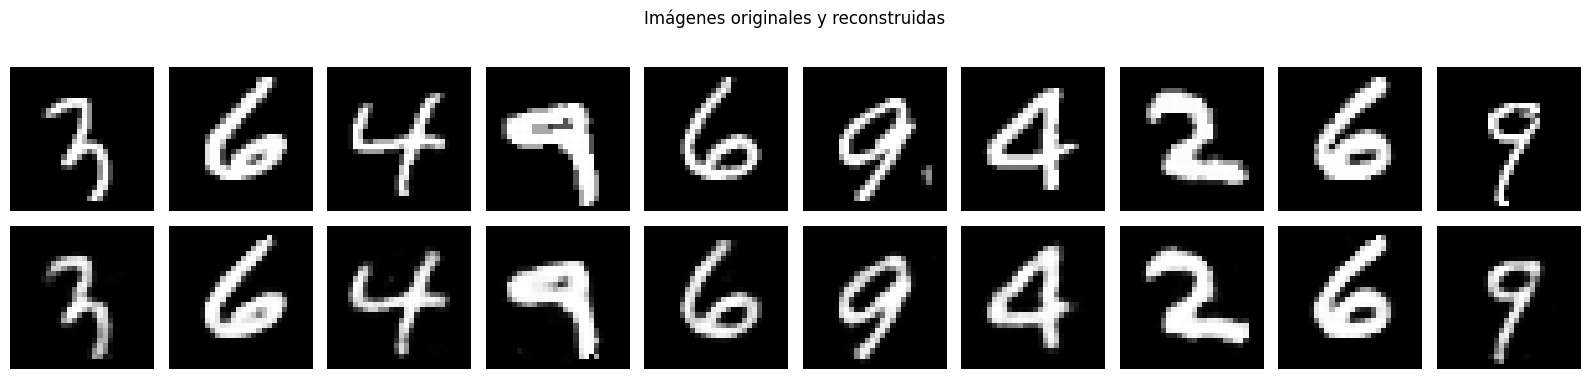

In [13]:
X_recon = autoencoder.predict(X[:10], verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i in range(10):
    axes[0, i].imshow(X[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(X_recon[i].reshape(28, 28), cmap="gray")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", rotation=90, size=11)
axes[1, 0].set_ylabel("Reconstrucción", rotation=90, size=11)

plt.suptitle("Imágenes originales y reconstruidas")
plt.tight_layout()
plt.show()

### Obtener el espacio latente y aplicar K-Means

Cada imagen original de 784 características se transforma ahora en un vector latente de 32 características.

In [14]:
inicio = time.perf_counter()

Z = encoder.predict(X, batch_size=512, verbose=0)

kmeans_ae = KMeans(n_clusters=N_CLUSTERS, n_init=20, random_state=RANDOM_STATE)
labels_ae = kmeans_ae.fit_predict(Z)
tiempo_cluster_ae = time.perf_counter() - inicio
tiempo_ae_total = tiempo_entrenamiento_ae + tiempo_cluster_ae

print("Forma del espacio latente:", Z.shape)
print(f"Tiempo de extracción + K-Means: {tiempo_cluster_ae:.2f} s")
print(f"Tiempo total Autoencoder + K-Means: {tiempo_ae_total:.2f} s")

Forma del espacio latente: (20000, 100)
Tiempo de extracción + K-Means: 2.06 s
Tiempo total Autoencoder + K-Means: 26.06 s


### Visualización del espacio latente

El espacio latente tiene 32 dimensiones. Para visualizarlo se utiliza una proyección PCA a dos dimensiones únicamente con fines gráficos.

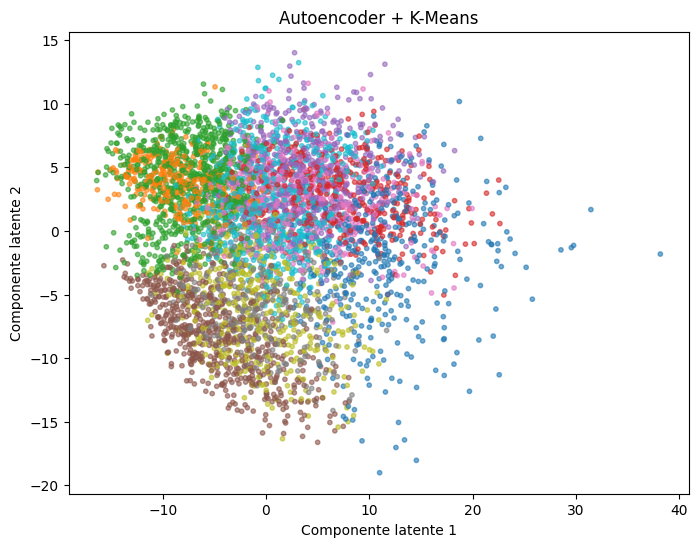

In [15]:
pca_latente_vis = PCA(n_components=2, random_state=RANDOM_STATE)
Z_2d = pca_latente_vis.fit_transform(Z)

plt.figure(figsize=(8, 6))
plt.scatter(
    Z_2d[muestra_plot, 0],
    Z_2d[muestra_plot, 1],
    c=labels_ae[muestra_plot],
    cmap="tab10",
    s=10,
    alpha=0.6
)
plt.xlabel("Componente latente 1")
plt.ylabel("Componente latente 2")
plt.title("Autoencoder + K-Means")
plt.show()

## 6. Evaluación de los tres métodos

Se compararán las tres estrategias utilizando métricas internas y externas.

Métricas internas:

- Silhouette: valores mayores indican clusters más compactos y separados.
- Davies-Bouldin: valores menores indican una mejor separación entre clusters.
- Calinski-Harabasz: valores mayores indican una mejor relación entre separación y compactación.
- SE: suma de los errores cuadrados respecto al centroide de cada cluster. Valores menores indican mayor compactación.

Métricas externas:

- ARI: mide la concordancia entre los clusters obtenidos y las clases reales, corrigiendo el acuerdo esperado por azar.
- NMI: mide la información compartida entre los clusters encontrados y las clases reales.

Las etiquetas reales de MNIST se utilizan únicamente para evaluar ARI y NMI. No intervienen en el entrenamiento de K-Means, PCA ni del autoencoder.

In [27]:
def evaluar_clustering(
    nombre,
    representacion,
    labels,
    modelo_kmeans,
    y_true,
    sample_idx
):
    """
    Calcula métricas internas y externas para una solución de clustering.

    Métricas internas:
    - Silhouette: mayor es mejor
    - Davies-Bouldin: menor es mejor
    - Calinski-Harabasz: mayor es mejor
    - SE: menor es mejor

    Métricas externas:
    - ARI: mayor es mejor
    - NMI: mayor es mejor
    """

    # Muestra común para las métricas internas más costosas
    X_muestra = representacion[sample_idx]
    labels_muestra = labels[sample_idx]

    return {
        "Método": nombre,
        "Dimensiones": representacion.shape[1],
        "Silhouette": silhouette_score(X_muestra, labels_muestra),
        "Davies-Bouldin": davies_bouldin_score(X_muestra, labels_muestra),
        "Calinski-Harabasz": calinski_harabasz_score(X_muestra, labels_muestra        ),
        "SE": modelo_kmeans.inertia_,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels)
    }

# ---------------------------------------------------------
# Utilizar la misma muestra para evaluar los tres métodos
# ---------------------------------------------------------

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X), size=min(3000, len(X)), replace=False)

# ---------------------------------------------------------
# Construir tabla de resultados
# ---------------------------------------------------------

resultados = pd.DataFrame([
    
    evaluar_clustering(
        "K-Means directo",
        X,
        labels_direct,
        kmeans_direct,
        y,
        sample_idx
    ),

    evaluar_clustering(
        "PCA + K-Means",
        X_pca,
        labels_pca,
        kmeans_pca,
        y,
        sample_idx
    ),

    evaluar_clustering("Autoencoder + K-Means", Z, labels_ae, kmeans_ae, y, sample_idx)
])

display(resultados.round(4))

,Método,Dimensiones,Silhouette,Davies-Bouldin,Calinski-Harabasz,SE,ARI,NMI
0,K-Means directo,784,0.0587,2.8612,116.4622,785613.5,0.3709,0.4862
1,PCA + K-Means,100,0.0700,2.6915,131.3911,695418.0,0.3699,0.4861
2,Autoencoder + K-Means,100,0.0848,2.5323,146.6834,4870244.0,0.2865,0.4117


In [20]:
# ---------------------------------------------------------
# Ranking de los métodos
# ---------------------------------------------------------

ranking = resultados.copy()

# Mayor es mejor
ranking["R_Silhouette"] = ranking["Silhouette"].rank(
    ascending=False,
    method="min"
)

ranking["R_Calinski-Harabasz"] = ranking["Calinski-Harabasz"].rank(
    ascending=False,
    method="min"
)

ranking["R_ARI"] = ranking["ARI"].rank(
    ascending=False,
    method="min"
)

ranking["R_NMI"] = ranking["NMI"].rank(
    ascending=False,
    method="min"
)

# Menor es mejor
ranking["R_Davies-Bouldin"] = ranking["Davies-Bouldin"].rank(
    ascending=True,
    method="min"
)

ranking["R_SE"] = ranking["SE"].rank(
    ascending=True,
    method="min"
)


# Suma de posiciones
columnas_ranking = [
    "R_Silhouette",
    "R_Davies-Bouldin",
    "R_Calinski-Harabasz",
    "R_SE",
    "R_ARI",
    "R_NMI"
]

ranking["Puntuación ranking"] = ranking[
    columnas_ranking
].sum(axis=1)


# Ranking final:
# menor puntuación acumulada = mejor resultado
ranking["Ranking final"] = ranking[
    "Puntuación ranking"
].rank(
    ascending=True,
    method="min"
).astype(int)


ranking_final = ranking[[
    "Método",
    "R_Silhouette",
    "R_Davies-Bouldin",
    "R_Calinski-Harabasz",
    "R_SE",
    "R_ARI",
    "R_NMI",
    "Puntuación ranking",
    "Ranking final"
]].sort_values("Ranking final")


display(ranking_final)

,Método,R_Silhouette,R_Davies-Bouldin,R_Calinski-Harabasz,R_SE,R_ARI,R_NMI,Puntuación ranking,Ranking final
1,PCA + K-Means,2.0,2.0,2.0,1.0,2.0,2.0,11.0,1
2,Autoencoder + K-Means,1.0,1.0,1.0,3.0,3.0,3.0,12.0,2
0,K-Means directo,3.0,3.0,3.0,2.0,1.0,1.0,13.0,3


### Tabla de reducción dimensional

Esta tabla resume cuántas variables utiliza K-Means en cada estrategia.

In [17]:
tabla_dimensiones = pd.DataFrame({
    "Método": [
        "K-Means directo",
        "PCA + K-Means",
        "Autoencoder + K-Means"
    ],
    "Dimensión usada por K-Means": [
        X.shape[1],
        X_pca.shape[1],
        Z.shape[1]
    ]
})

tabla_dimensiones["Reducción respecto a 784 (%)"] = (
    100 * (1 - tabla_dimensiones["Dimensión usada por K-Means"] / X.shape[1])
)

tabla_dimensiones.round(2)

,Método,Dimensión usada por K-Means,Reducción respecto a 784 (%)
0,K-Means directo,784,0.00
1,PCA + K-Means,100,87.24
2,Autoencoder + K-Means,100,87.24


### Comparación gráfica de las métricas externas

Valores mayores indican una mayor correspondencia entre la estructura encontrada por los clusters y las etiquetas reales.

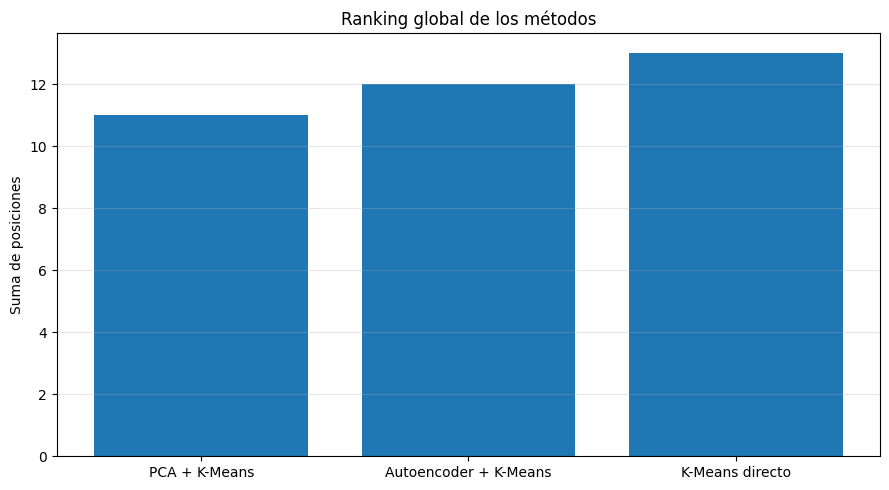

In [21]:
ranking_grafica = ranking_final.sort_values(
    "Puntuación ranking",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.bar(
    ranking_grafica["Método"],
    ranking_grafica["Puntuación ranking"]
)

plt.ylabel("Suma de posiciones")
plt.title("Ranking global de los métodos")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. ¿Qué representa cada cluster?

Los centroides permiten obtener una idea visual del patrón representativo aprendido por cada método.

Para K-Means directo, cada centroide ya contiene 784 valores y puede reconstruirse como una imagen de 28 × 28.

Para PCA + K-Means, los centroides se llevan nuevamente al espacio original utilizando inverse_transform.

Para Autoencoder + K-Means, los centroides del espacio latente se pasan por el decoder para obtener una reconstrucción en el espacio de los píxeles.

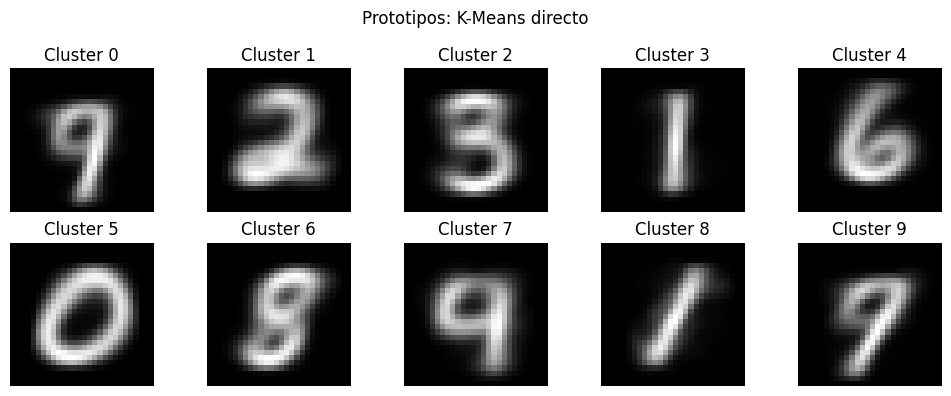

In [23]:
def mostrar_prototipos(imagenes, titulo):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.ravel()):
        ax.imshow(imagenes[i].reshape(28, 28), cmap="gray")
        ax.set_title(f"Cluster {i}")
        ax.axis("off")
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

# Centroides directos
prototipos_direct = kmeans_direct.cluster_centers_
mostrar_prototipos(prototipos_direct, "Prototipos: K-Means directo")

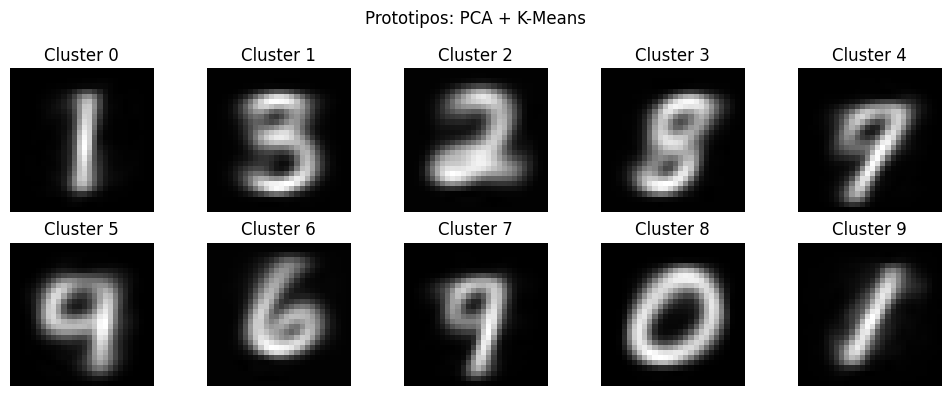

In [24]:
# Centroides de PCA llevados de nuevo al espacio original
prototipos_pca = pca.inverse_transform(kmeans_pca.cluster_centers_)
mostrar_prototipos(prototipos_pca, "Prototipos: PCA + K-Means")

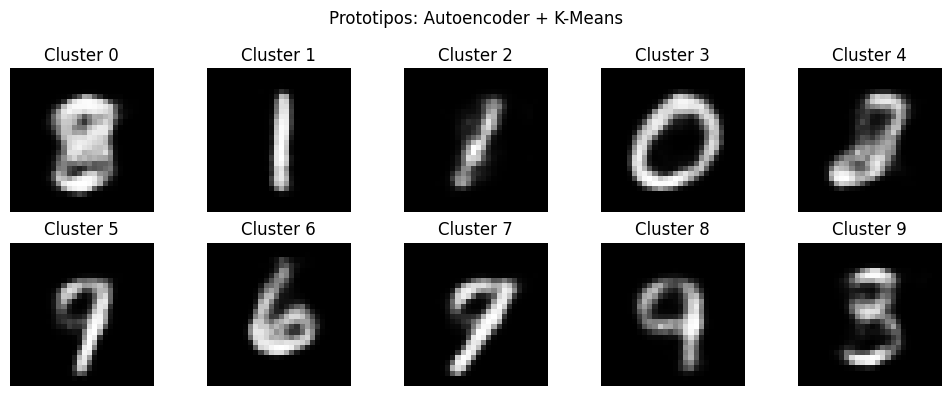

In [25]:
# Centroides latentes reconstruidos mediante el decoder
prototipos_ae = decoder.predict(kmeans_ae.cluster_centers_, verbose=0)
mostrar_prototipos(prototipos_ae, "Prototipos: Autoencoder + K-Means")